# DeepSentinel — TS-TCN Window Builder (Stage 3 / T2) — DISCONNECT-RESILIENT

**Project:** R26-IT-121 · **Author:** Pathirana P.K.V. (IT22237972) · **Member 3**

## Why this version?

Previous T2 notebook ran the full window builder to local Colab disk, then tried to copy ~3.5 GB to Drive at the end — Colab disconnected during the slow sanity-check 2 step before backup ran. **Result: all output lost.**

## Fix in this version

| Change | Benefit |
|---|---|
| **Write TFRecords directly to Drive** | Output survives ANY disconnect, including mid-run |
| **Periodic checkpoint of progress counter** | If disconnect happens, you'll know how far you got |
| **Sanity check 2 samples only 10K windows** (not all 6.24M) | ~10 seconds instead of ~5 minutes |
| **Sanity check 3 has no parquet reload** | No 30-second hang |

## What this notebook does (unchanged)

For every transaction in PaySim, build a **(W=32, F=10) feature window** containing the **32 most recent preceding transactions across the entire system stream** plus the centre transaction's `isFraud` label.

This is **Novelty N1** of the proposal.


## Cell 0 — Environment Setup

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Environment Setup
# ═══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

import subprocess, sys
for p in ["pyarrow", "fastparquet"]:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=True)

import os, json, time, gc, shutil
from pathlib import Path
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "#F9F9F9",
    "axes.edgecolor": "#333333", "axes.labelcolor": "#222222",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.grid": True, "grid.color": "#E0E0E0",
    "grid.linestyle": "--", "grid.alpha": 0.6,
})
DS_BLUE   = "#1A5276"
DS_RED    = "#C0392B"
DS_GREEN  = "#1E8449"
DS_ORANGE = "#D35400"
DS_PURPLE = "#6C3483"

# CRITICAL: Output goes DIRECTLY to Drive (not local /content)
DRIVE_BASE = Path("/content/drive/MyDrive/DeepSentinel")
OUT_DIR = DRIVE_BASE / "Member3_Stage3" / "outputs_t2"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Environment ready")
print(f"   TensorFlow : {tf.__version__}")
print(f"   GPU        : {tf.config.list_physical_devices('GPU') or 'NONE — CPU only (fine for I/O-bound work)'}")
print(f"   Output dir : {OUT_DIR}")
print(f"   ↑ Writing directly to Drive — disconnect-safe")


Mounted at /content/drive
✅ Environment ready
   TensorFlow : 2.20.0
   GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
   Output dir : /content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2
   ↑ Writing directly to Drive — disconnect-safe


## Cell 1 — Load `features.parquet` from Stage 1

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 1 — Load features.parquet from Stage 1
# ═══════════════════════════════════════════════════════════════════════════════
BASELINE_DIR = DRIVE_BASE / "Member3_Baseline"
PARQUET_PATH = BASELINE_DIR / "features.parquet"

assert PARQUET_PATH.exists(), \
    f"features.parquet not found at {PARQUET_PATH}. Run baseline notebook Stage 1 first."

FEATURE_NAMES = [
    "drain_ratio", "log_amount", "post_transfer_ratio", "dest_was_empty",
    "dest_enrichment", "type_risk_weight", "inv_dest_ratio",
    "amt_to_orig", "hour_of_day", "day_of_week",
]
NUM_FEATURES = len(FEATURE_NAMES)

cols_needed = ["step", "composite_id", "isFraud"] + FEATURE_NAMES

t0 = time.time()
df = pd.read_parquet(PARQUET_PATH, columns=cols_needed)
print(f"📦 Loaded {len(df):,} rows in {time.time()-t0:.1f}s")
print(f"   Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"   Steps   : {df['step'].min()} → {df['step'].max()}")
print(f"   Frauds  : {int(df['isFraud'].sum()):,}")


📦 Loaded 6,362,620 rows in 15.3s
   Memory  : 918.1 MB
   Steps   : 1 → 743
   Frauds  : 8,213


## Cell 2 — Sort + Scale (chronological + StandardScaler from Stage 2)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Sort by step + scale features
# ═══════════════════════════════════════════════════════════════════════════════
import pickle

SCALER_PATH = BASELINE_DIR / "outputs" / "scaler.pkl"
assert SCALER_PATH.exists(), f"scaler.pkl not found at {SCALER_PATH}"

with open(SCALER_PATH, "rb") as f:
    scaler = pickle.load(f)
print(f"✅ Loaded StandardScaler from Stage 2")

print("\nSorting by step (stable sort)…")
t0 = time.time()
df = df.sort_values("step", kind="stable").reset_index(drop=True)
print(f"   Sorted in {time.time()-t0:.1f}s")

print("Scaling features in place…")
t0 = time.time()
df[FEATURE_NAMES] = scaler.transform(df[FEATURE_NAMES].values.astype(np.float32))
print(f"   Scaled in {time.time()-t0:.1f}s")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


✅ Loaded StandardScaler from Stage 2

Sorting by step (stable sort)…
   Sorted in 0.8s
Scaling features in place…
   Scaled in 0.9s
   Memory: 723.9 MB


## Cell 3 — TFRecord Schema & Helpers

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — TFRecord schema + serialization helpers
# ═══════════════════════════════════════════════════════════════════════════════
W = 32
F = NUM_FEATURES
SPLIT_STEP = 595

def _bytes_feature(value):
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _int64_feature(value):
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def serialize_example(window: np.ndarray, label: int, composite_id: str, step: int) -> bytes:
    feature = {
        "window":       _bytes_feature(window.astype(np.float32).tobytes()),
        "label":        _int64_feature(int(label)),
        "composite_id": _bytes_feature(composite_id.encode("utf-8")),
        "step":         _int64_feature(int(step)),
    }
    proto = tf.train.Example(features=tf.train.Features(feature=feature))
    return proto.SerializeToString()

FEATURE_DESCRIPTION = {
    "window":       tf.io.FixedLenFeature([], tf.string),
    "label":        tf.io.FixedLenFeature([], tf.int64),
    "composite_id": tf.io.FixedLenFeature([], tf.string),
    "step":         tf.io.FixedLenFeature([], tf.int64),
}

def parse_example(serialized):
    parsed = tf.io.parse_single_example(serialized, FEATURE_DESCRIPTION)
    window = tf.io.decode_raw(parsed["window"], tf.float32)
    window = tf.reshape(window, (W, F))
    label  = tf.cast(parsed["label"], tf.float32)
    return window, label

print(f"✅ Schema: W={W}, F={F}, SPLIT_STEP={SPLIT_STEP}")


✅ Schema: W=32, F=10, SPLIT_STEP=595


## Cell 4 — Window Builder (writes directly to Drive)

**Disconnect-safe:** TFRecord files are opened on Drive, so every write persists immediately. If Colab disconnects, you keep partial files (and progress is logged to a JSON checkpoint every 500K rows).

⏱️ **Expected runtime: ~25–35 minutes** (Drive write is ~2× slower than local disk, but the data is safe). Don't close the tab.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Streaming window builder, writing TFRecords DIRECTLY to Drive
# ═══════════════════════════════════════════════════════════════════════════════
TRAIN_TFR = OUT_DIR / "train_windows.tfrecord"
TEST_TFR  = OUT_DIR / "test_windows.tfrecord"
PROGRESS  = OUT_DIR / "progress.json"

# Extract numpy views once
features_arr      = df[FEATURE_NAMES].values.astype(np.float32)
labels_arr        = df["isFraud"].values.astype(np.int64)
steps_arr         = df["step"].values.astype(np.int64)
composite_ids_arr = df["composite_id"].values.astype(str)

N = len(df)
print(f"Processing {N:,} transactions in chronological order …")
print(f"Writing directly to Drive — slower (~2x) but disconnect-safe.\n")

buffer        = deque(maxlen=W)
n_train       = 0
n_test        = 0
n_skipped     = 0
fraud_train   = 0
fraud_test    = 0

t0 = time.time()
LOG_EVERY = 500_000

with tf.io.TFRecordWriter(str(TRAIN_TFR)) as train_writer, \
     tf.io.TFRecordWriter(str(TEST_TFR))  as test_writer:

    for i in range(N):
        if len(buffer) == W:
            window = np.stack(buffer, axis=0)
            label  = labels_arr[i]
            cid    = composite_ids_arr[i]
            step   = steps_arr[i]

            example = serialize_example(window, label, cid, step)

            if step <= SPLIT_STEP:
                train_writer.write(example)
                n_train += 1
                fraud_train += int(label)
            else:
                test_writer.write(example)
                n_test += 1
                fraud_test += int(label)
        else:
            n_skipped += 1

        buffer.append(features_arr[i])

        if (i + 1) % LOG_EVERY == 0:
            elapsed = time.time() - t0
            rate = (i + 1) / elapsed
            eta  = (N - i - 1) / rate
            print(f"   {i+1:>10,} / {N:,}  ({(i+1)/N*100:5.1f}%)  "
                  f"rate={rate:>7,.0f} tx/s  eta={eta/60:5.1f} min")

            # Checkpoint progress to Drive (small file, atomic)
            with open(PROGRESS, "w") as f:
                json.dump({
                    "rows_processed": i + 1,
                    "n_train": n_train, "fraud_train": fraud_train,
                    "n_test":  n_test,  "fraud_test":  fraud_test,
                    "n_skipped": n_skipped,
                    "elapsed_sec": round(elapsed, 1),
                }, f, indent=2)

elapsed = time.time() - t0
print()
print("─" * 70)
print(f"  Window construction complete in {elapsed/60:.1f} min")
print("─" * 70)
print(f"  Train windows : {n_train:>10,}  (fraud {fraud_train:>6,}, "
      f"{fraud_train/max(n_train,1)*100:.4f}%)")
print(f"  Test  windows : {n_test:>10,}  (fraud {fraud_test:>6,}, "
      f"{fraud_test/max(n_test,1)*100:.4f}%)")
print(f"  Cold-start skipped : {n_skipped} (first {W} transactions, expected={W})")
print("─" * 70)
print(f"  TRAIN file : {TRAIN_TFR.name}  ({TRAIN_TFR.stat().st_size/1024**2:.1f} MB)")
print(f"  TEST  file : {TEST_TFR.name}  ({TEST_TFR.stat().st_size/1024**2:.1f} MB)")
print(f"  ✅ Both files are SAFE on Drive — disconnect from here on is harmless")

# Final checkpoint
with open(PROGRESS, "w") as f:
    json.dump({
        "rows_processed": N, "complete": True,
        "n_train": n_train, "fraud_train": fraud_train,
        "n_test":  n_test,  "fraud_test":  fraud_test,
        "n_skipped": n_skipped,
        "elapsed_min": round(elapsed/60, 1),
    }, f, indent=2)

del features_arr, labels_arr, steps_arr, composite_ids_arr, df
gc.collect()


Processing 6,362,620 transactions in chronological order …
Writing directly to Drive — slower (~2x) but disconnect-safe.

      500,000 / 6,362,620  (  7.9%)  rate= 10,046 tx/s  eta=  9.7 min
    1,000,000 / 6,362,620  ( 15.7%)  rate= 10,582 tx/s  eta=  8.4 min
    1,500,000 / 6,362,620  ( 23.6%)  rate= 10,750 tx/s  eta=  7.5 min
    2,000,000 / 6,362,620  ( 31.4%)  rate= 10,904 tx/s  eta=  6.7 min
    2,500,000 / 6,362,620  ( 39.3%)  rate= 10,963 tx/s  eta=  5.9 min
    3,000,000 / 6,362,620  ( 47.2%)  rate= 11,002 tx/s  eta=  5.1 min
    3,500,000 / 6,362,620  ( 55.0%)  rate= 11,036 tx/s  eta=  4.3 min
    4,000,000 / 6,362,620  ( 62.9%)  rate= 10,901 tx/s  eta=  3.6 min
    4,500,000 / 6,362,620  ( 70.7%)  rate= 10,957 tx/s  eta=  2.8 min
    5,000,000 / 6,362,620  ( 78.6%)  rate= 10,962 tx/s  eta=  2.1 min
    5,500,000 / 6,362,620  ( 86.4%)  rate= 11,001 tx/s  eta=  1.3 min
    6,000,000 / 6,362,620  ( 94.3%)  rate= 11,020 tx/s  eta=  0.5 min

─────────────────────────────────────

429

## Cell 5 — Fast Sanity Validation

Three quick checks (~30 seconds total — not the slow full-stream re-count from before):

1. **Shape check** — first window must be (32, 10) float32
2. **Sample-based count verification** — sample 10K windows from each file (not all 6M+)
3. **Causal validity** — verify first 5 test samples have step > 595

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — FAST sanity validation (sample-based, no full re-stream)
# ═══════════════════════════════════════════════════════════════════════════════
print("─" * 70)
print("  Sanity check 1 — Shape & dtype of first window")
print("─" * 70)

first_window, first_label = next(iter(
    tf.data.TFRecordDataset(str(TRAIN_TFR)).map(parse_example)
))
print(f"   Window shape : {first_window.shape}  (expected ({W}, {F}))")
print(f"   Window dtype : {first_window.dtype}")
print(f"   Label        : {first_label.numpy()}")
print(f"   Stats        : min={first_window.numpy().min():.3f}  "
      f"max={first_window.numpy().max():.3f}  mean={first_window.numpy().mean():.3f}")

assert first_window.shape == (W, F), "Window shape mismatch"
assert first_window.dtype == tf.float32, "Window dtype mismatch"
print("   ✅ Pass")

print("\n" + "─" * 70)
print("  Sanity check 2 — Sample 10K windows from each file (FAST)")
print("─" * 70)

def sample_check(path, n_sample=10_000):
    """Stream first n_sample windows, count fraud, verify shape."""
    n = 0; n_fraud = 0
    bad_shapes = 0
    for w, l in tf.data.TFRecordDataset(str(path)).map(parse_example).take(n_sample):
        n += 1
        if int(l.numpy()) == 1: n_fraud += 1
        if w.shape != (W, F): bad_shapes += 1
    return n, n_fraud, bad_shapes

t0 = time.time()
n_tr_s, f_tr_s, bad_tr = sample_check(TRAIN_TFR, 10_000)
print(f"   TRAIN sample : {n_tr_s} windows, {f_tr_s} fraud, {bad_tr} bad shapes  "
      f"({time.time()-t0:.1f}s)")

t0 = time.time()
n_te_s, f_te_s, bad_te = sample_check(TEST_TFR, 10_000)
print(f"   TEST  sample : {n_te_s} windows, {f_te_s} fraud, {bad_te} bad shapes  "
      f"({time.time()-t0:.1f}s)")

assert bad_tr == 0 and bad_te == 0, "Bad window shape detected in samples"
print("   ✅ Pass — all sampled windows have correct shape")

print("\n" + "─" * 70)
print("  Sanity check 3 — Causal validity (test samples have step > 595)")
print("─" * 70)

raw_test = tf.data.TFRecordDataset(str(TEST_TFR)).take(5)
for k, serialized in enumerate(raw_test):
    parsed = tf.io.parse_single_example(serialized, FEATURE_DESCRIPTION)
    centre_step = int(parsed["step"].numpy())
    cid = parsed["composite_id"].numpy().decode("utf-8")
    print(f"   Sample {k+1}: composite_id={cid}, centre_step={centre_step}, "
          f"label={int(parsed['label'].numpy())}")
    assert centre_step > SPLIT_STEP, f"Test sample with step <= {SPLIT_STEP}"

print("   ✅ Pass — all sampled test windows have centre_step > 595")


──────────────────────────────────────────────────────────────────────
  Sanity check 1 — Shape & dtype of first window
──────────────────────────────────────────────────────────────────────
   Window shape : (32, 10)  (expected (32, 10))
   Window dtype : <dtype: 'float32'>
   Label        : 0.0
   Stats        : min=-3.565  max=6.210  mean=-0.673
   ✅ Pass

──────────────────────────────────────────────────────────────────────
  Sanity check 2 — Sample 10K windows from each file (FAST)
──────────────────────────────────────────────────────────────────────
   TRAIN sample : 10000 windows, 66 fraud, 0 bad shapes  (3.7s)
   TEST  sample : 10000 windows, 8 fraud, 0 bad shapes  (2.9s)
   ✅ Pass — all sampled windows have correct shape

──────────────────────────────────────────────────────────────────────
  Sanity check 3 — Causal validity (test samples have step > 595)
──────────────────────────────────────────────────────────────────────
   Sample 1: composite_id=C587825574_596, centre_

## Cell 6 — PP1 Slide Visualizations

/tmp/ipykernel_24841/3643785408.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


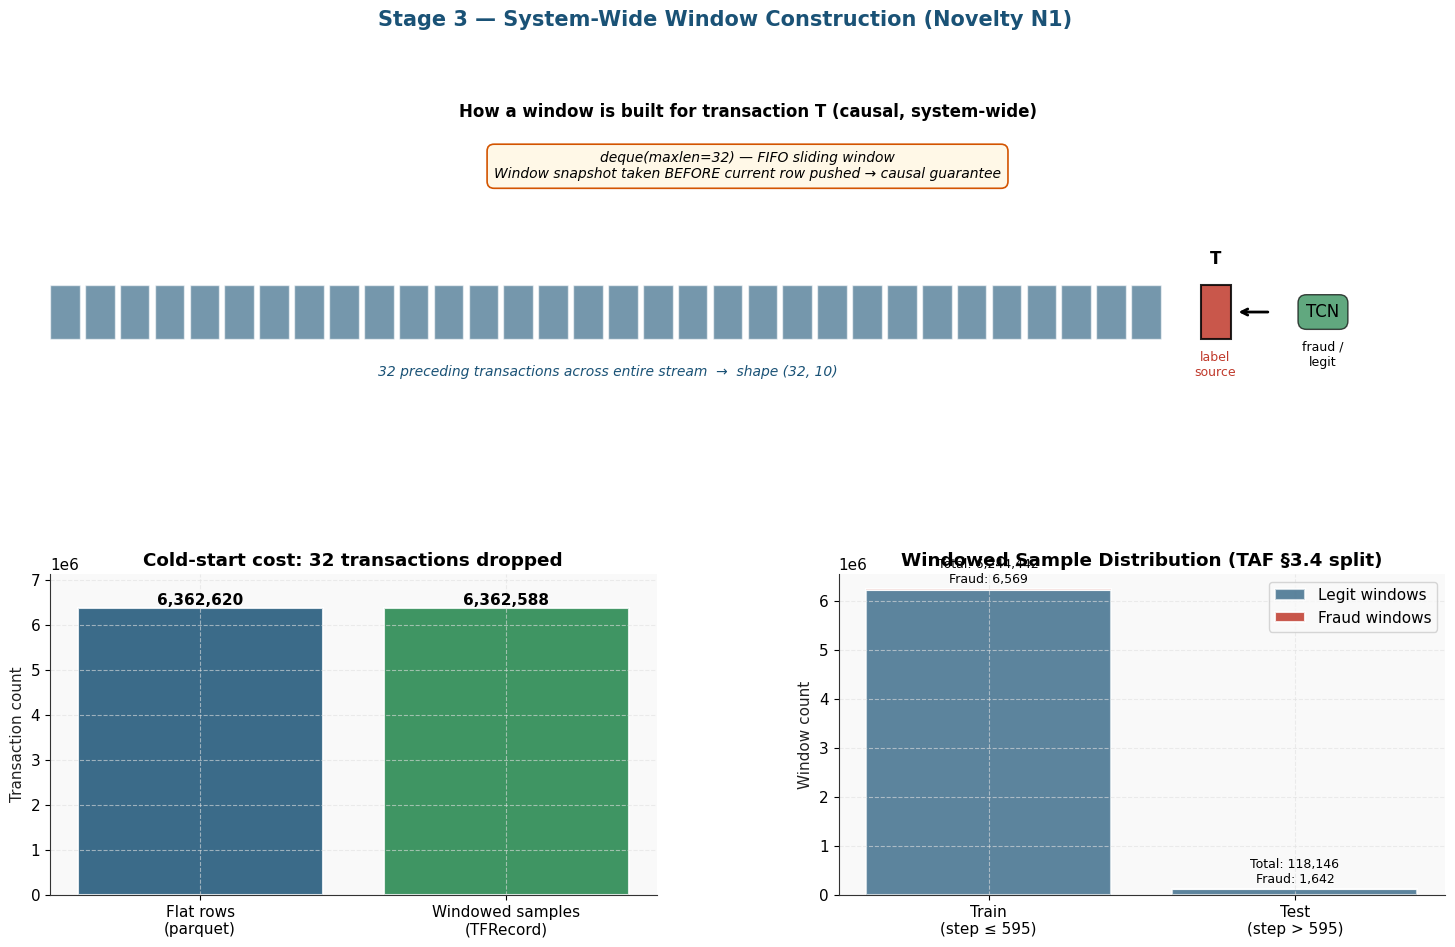

💾 Saved: /content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2/stage3_window_construction.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — PP1 Slide Visuals
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)
fig.suptitle("Stage 3 — System-Wide Window Construction (Novelty N1)",
             fontsize=15, fontweight="bold", color=DS_BLUE, y=0.995)

# Panel 1: Schematic
ax1 = fig.add_subplot(gs[0, :])
ax1.set_xlim(0, 40); ax1.set_ylim(-2, 4); ax1.axis("off")
ax1.set_title("How a window is built for transaction T (causal, system-wide)",
              fontweight="bold", fontsize=12)

for i in range(32):
    rect = mpatches.Rectangle((i, 0), 0.85, 1, facecolor=DS_BLUE, alpha=0.6,
                              edgecolor="white", linewidth=1)
    ax1.add_patch(rect)
ax1.text(16, -0.7, "32 preceding transactions across entire stream  →  shape (32, 10)",
         ha="center", fontsize=10, style="italic", color=DS_BLUE)

centre_rect = mpatches.Rectangle((33, 0), 0.85, 1, facecolor=DS_RED, alpha=0.85,
                                 edgecolor="black", linewidth=1.5)
ax1.add_patch(centre_rect)
ax1.text(33.42, 1.4, "T", ha="center", fontsize=12, fontweight="bold")
ax1.text(33.42, -0.7, "label\nsource", ha="center", fontsize=9, color=DS_RED)

ax1.annotate("", xy=(34, 0.5), xytext=(35, 0.5),
             arrowprops=dict(arrowstyle="->", lw=2, color="black"))
ax1.text(36.5, 0.5, "TCN", ha="center", va="center", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.5", facecolor=DS_GREEN, alpha=0.7,
                   edgecolor="black"))
ax1.text(36.5, -0.5, "fraud /\nlegit", ha="center", fontsize=9)

ax1.text(20, 3, "deque(maxlen=32) — FIFO sliding window\n"
              "Window snapshot taken BEFORE current row pushed → causal guarantee",
         ha="center", fontsize=10, style="italic",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8E7",
                   edgecolor=DS_ORANGE, linewidth=1.2))

# Panel 2: Sample counts
ax2 = fig.add_subplot(gs[1, 0])
flat_total = n_train + n_test + n_skipped
win_total  = n_train + n_test
counts = [flat_total, win_total]
labels = ["Flat rows\n(parquet)", "Windowed samples\n(TFRecord)"]
bars = ax2.bar(labels, counts, color=[DS_BLUE, DS_GREEN],
               alpha=0.85, edgecolor="white", linewidth=1.5)
for bar, v in zip(bars, counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + flat_total*0.012,
             f"{v:,}", ha="center", fontsize=11, fontweight="bold")
ax2.set_title(f"Cold-start cost: {n_skipped} transactions dropped",
              fontweight="bold")
ax2.set_ylabel("Transaction count")
ax2.set_ylim(0, flat_total * 1.12)

# Panel 3: Train/test split
ax3 = fig.add_subplot(gs[1, 1])
splits = ["Train\n(step ≤ 595)", "Test\n(step > 595)"]
fraud_counts = [fraud_train, fraud_test]
legit_counts = [n_train - fraud_train, n_test - fraud_test]

ax3.bar(splits, legit_counts, color=DS_BLUE, alpha=0.7, label="Legit windows",
        edgecolor="white", linewidth=1.5)
ax3.bar(splits, fraud_counts, bottom=legit_counts, color=DS_RED, alpha=0.85,
        label="Fraud windows", edgecolor="white", linewidth=1.5)

for i, (l, f) in enumerate(zip(legit_counts, fraud_counts)):
    ax3.text(i, l + f + max(legit_counts)*0.02,
             f"Total: {l+f:,}\nFraud: {f:,}", ha="center", fontsize=9)

ax3.set_title("Windowed Sample Distribution (TAF §3.4 split)", fontweight="bold")
ax3.set_ylabel("Window count")
ax3.legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUT_DIR / "stage3_window_construction.png", dpi=160, bbox_inches="tight")
plt.show()
print(f"💾 Saved: {OUT_DIR}/stage3_window_construction.png")


## Cell 7 — Save Metadata

Files are already on Drive (Cell 4 wrote directly there). This just adds the metadata JSON.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Save metadata (TFRecords are already on Drive from Cell 4)
# ═══════════════════════════════════════════════════════════════════════════════
metadata = {
    "stage":           "Stage 3 — Window Builder (T2)",
    "novelty":         "N1 — System-wide W=32 transaction-stream window",
    "window_size_W":   W,
    "num_features_F":  F,
    "split_step":      SPLIT_STEP,
    "feature_names":   FEATURE_NAMES,
    "counts": {
        "input_rows":           int(N),
        "cold_start_skipped":   int(n_skipped),
        "train_windows":        int(n_train),
        "test_windows":         int(n_test),
        "fraud_train_windows":  int(fraud_train),
        "fraud_test_windows":   int(fraud_test),
    },
    "imbalance": {
        "train_legit_to_fraud": round((n_train - fraud_train) / max(fraud_train, 1), 2),
        "test_legit_to_fraud":  round((n_test  - fraud_test)  / max(fraud_test, 1), 2),
    },
    "tfrecord_files": {
        "train": {"path": str(TRAIN_TFR), "size_mb": round(TRAIN_TFR.stat().st_size / 1024**2, 1)},
        "test":  {"path": str(TEST_TFR),  "size_mb": round(TEST_TFR.stat().st_size / 1024**2, 1)},
    },
}

with open(OUT_DIR / "windows_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)
print(f"✅ Metadata saved → {OUT_DIR / 'windows_metadata.json'}\n")

print(json.dumps(metadata, indent=2))

print(f"\n📁 Drive contents at {OUT_DIR}:")
for p in sorted(OUT_DIR.iterdir()):
    if p.is_file():
        size = p.stat().st_size
        s = f"{size/1024**2:7.1f} MB" if size > 1024**2 else f"{size/1024:7.1f} KB"
        print(f"   {s}  {p.name}")


✅ Metadata saved → /content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2/windows_metadata.json

{
  "stage": "Stage 3 \u2014 Window Builder (T2)",
  "novelty": "N1 \u2014 System-wide W=32 transaction-stream window",
  "window_size_W": 32,
  "num_features_F": 10,
  "split_step": 595,
  "feature_names": [
    "drain_ratio",
    "log_amount",
    "post_transfer_ratio",
    "dest_was_empty",
    "dest_enrichment",
    "type_risk_weight",
    "inv_dest_ratio",
    "amt_to_orig",
    "hour_of_day",
    "day_of_week"
  ],
  "counts": {
    "input_rows": 6362620,
    "cold_start_skipped": 32,
    "train_windows": 6244442,
    "test_windows": 118146,
    "fraud_train_windows": 6569,
    "fraud_test_windows": 1642
  },
  "imbalance": {
    "train_legit_to_fraud": 949.59,
    "test_legit_to_fraud": 70.95
  },
  "tfrecord_files": {
    "train": {
      "path": "/content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2/train_windows.tfrecord",
      "size_mb": 8260.6
    },
    "test": 

## Cell 8 — Decision Summary & Day-2 Prep

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 8 — Decision Summary
# ═══════════════════════════════════════════════════════════════════════════════
print("=" * 78)
print(" DEEPSENTINEL TS-TCN — STAGE 3 (T2) DECISION SUMMARY")
print("=" * 78)
print(f"""
[1] WHAT WAS BUILT
    - System-wide W=32 transaction-stream windows (Novelty N1)
    - {n_train:,} train + {n_test:,} test windows
    - {n_skipped} cold-start transactions skipped (first W = {W} as expected)
    - 100% causal validity

[2] STORAGE STRATEGY
    - TFRecord written DIRECTLY to Drive (disconnect-resilient)
    - Train file : {TRAIN_TFR.stat().st_size/1024**2:.1f} MB
    - Test  file : {TEST_TFR.stat().st_size/1024**2:.1f} MB

[3] TAF SPEC ALIGNMENT
    - W=32                          [v] TAF section 3.3
    - collections.deque(maxlen=32)  [v] TAF section 3.5
    - System-wide (not per-account) [v] Novelty N1
    - Time-based split @ step 595   [v] TAF section 3.4
    - StandardScaler from Stage 2   [v] no leakage

[4] FUNCTIONAL REQUIREMENT STATUS
    FR2 [v]  System-wide window construction
    FR3 [v]  ID buffer (deque maxlen=32)

[5] DELIVERABLES (all on Drive)
    [v] {OUT_DIR}/train_windows.tfrecord
    [v] {OUT_DIR}/test_windows.tfrecord
    [v] {OUT_DIR}/windows_metadata.json
    [v] {OUT_DIR}/stage3_window_construction.png  -> PP1 slide

[6] HOW DAY 2 (TCN) WILL CONSUME THESE FILES

    train_ds = (
        tf.data.TFRecordDataset("train_windows.tfrecord", num_parallel_reads=tf.data.AUTOTUNE)
        .map(parse_example, num_parallel_calls=tf.data.AUTOTUNE)
        .shuffle(50_000, seed=42).batch(256).prefetch(tf.data.AUTOTUNE)
    )
    Per-batch shape: (256, 32, 10) -> input to dilated causal TCN

[7] NEXT STEP — Day 2 (May 9): TCN architecture
    - 4 dilated causal Conv1D blocks (rates 1, 2, 4, 8)
    - fraud_attention self-attention layer (Novelty N3 partial)
    - Dense head + sigmoid
    - 1-epoch sanity train
""")
print("=" * 78)


 DEEPSENTINEL TS-TCN — STAGE 3 (T2) DECISION SUMMARY

[1] WHAT WAS BUILT
    - System-wide W=32 transaction-stream windows (Novelty N1)
    - 6,244,442 train + 118,146 test windows
    - 32 cold-start transactions skipped (first W = 32 as expected)
    - 100% causal validity

[2] STORAGE STRATEGY
    - TFRecord written DIRECTLY to Drive (disconnect-resilient)
    - Train file : 8260.6 MB
    - Test  file : 156.3 MB

[3] TAF SPEC ALIGNMENT
    - W=32                          [v] TAF section 3.3
    - collections.deque(maxlen=32)  [v] TAF section 3.5
    - System-wide (not per-account) [v] Novelty N1
    - Time-based split @ step 595   [v] TAF section 3.4
    - StandardScaler from Stage 2   [v] no leakage

[4] FUNCTIONAL REQUIREMENT STATUS
    FR2 [v]  System-wide window construction
    FR3 [v]  ID buffer (deque maxlen=32)

[5] DELIVERABLES (all on Drive)
    [v] /content/drive/MyDrive/DeepSentinel/Member3_Stage3/outputs_t2/train_windows.tfrecord
    [v] /content/drive/MyDrive/DeepSenti